In [ ]:
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
# !pip install "transformers==4.56.1" "trl==0.20.0" "peft==0.18.0" -q
# !pip install "httpx>=0.27" "datasets>=2.18" pandas matplotlib bitsandbytes accelerate -q
# print("Done — Runtime → Restart Runtime → run from Cell 2")

In [ ]:
import os, warnings, logging

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("unsloth").setLevel(logging.ERROR)
logging.getLogger("trl").setLevel(logging.ERROR)

TRIAGE_ENV_BASE_URL = "https://vishaltechie-medical-triage-env.hf.space"
BASE_MODEL_NAME     = "unsloth/Qwen2.5-1.5B-Instruct"
MODEL_RUN_TAG       = BASE_MODEL_NAME.split("/")[-1].replace(".", "_")

TASK_IDS = ["classic-mi", "meningitis-suspect", "masked-sepsis"]

CORRECT_ESI_PER_TASK = {
    "classic-mi":         1,
    "meningitis-suspect": 1,
    "masked-sepsis":      2,
}

TASK_REQUIRES_CLARIFICATION = {
    "classic-mi":         False,
    "meningitis-suspect": False,
    "masked-sepsis":      True,
}

TASK_WEIGHTS = {
    "classic-mi":         1.2,
    "meningitis-suspect": 1.3,
    "masked-sepsis":      1.0,
}

MAX_PROMPT_TOKEN_LENGTH     = 800
MAX_COMPLETION_TOKEN_LENGTH = 256
GRPO_TRAIN_STEPS            = 80
GRPO_NUM_GENERATIONS        = 4
GRPO_GENERATION_TEMPERATURE = 1.1
EVAL_TEMPERATURE            = 0.3
TOTAL_DATASET_SAMPLES       = 63
EVAL_EPISODE_COUNT          = 30
LEARNING_RATE               = 1e-4
KL_BETA                     = 0.04
REQUEST_TIMEOUT             = 90.0
HTTP_MAX_RETRIES            = 3
HTTP_RETRY_BACKOFF          = 1.5

print(f"Model: {BASE_MODEL_NAME}")
print(f"Steps: {GRPO_TRAIN_STEPS} | Gens: {GRPO_NUM_GENERATIONS} | LR: {LEARNING_RATE}")
print(f"Dataset: {TOTAL_DATASET_SAMPLES} | Eval: {EVAL_EPISODE_COUNT}")
print(f"Train/eval temperature: {GRPO_GENERATION_TEMPERATURE}/{EVAL_TEMPERATURE}")

Model: unsloth/Qwen2.5-1.5B-Instruct
Steps: 80 | Gens: 4 | LR: 0.0001
Dataset: 63 | Eval: 30
Train/eval temperature: 1.1/0.3


In [ ]:
import torch

if not torch.cuda.is_available():
    raise SystemExit("No GPU available. Change the runtime type to a T4 GPU.")

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)
print(f"GPU: {gpu_name}  VRAM: {vram_gb} GB")
if vram_gb < 12:
    print("Memory below 12 GB, reducing GRPO_NUM_GENERATIONS to 3")
    GRPO_NUM_GENERATIONS = 3
print("GPU ready")

GPU: Tesla T4  VRAM: 15.6 GB
GPU ready


In [ ]:
import httpx, time

class TriageEnvClient:
    def __init__(self, base_url: str):
        self.base_url      = base_url.rstrip("/")
        self.session_id    = None
        self.last_task_id  = None
        self._client       = httpx.Client(timeout=REQUEST_TIMEOUT)

    def reset(self, task_id: str) -> dict:
        self.last_task_id = task_id
        last_err = None
        for attempt in range(HTTP_MAX_RETRIES):
            try:
                r = self._client.post(f"{self.base_url}/reset", json={"task_id": task_id})
                r.raise_for_status()
                data = r.json()
                self.session_id = data["info"]["session_id"]
                return data["observation"]
            except Exception as e:
                last_err = e
                if attempt < HTTP_MAX_RETRIES - 1:
                    time.sleep(HTTP_RETRY_BACKOFF * (attempt + 1))
        raise last_err

    def step(self, action: dict) -> dict:
        if not self.session_id:
            raise RuntimeError("call reset() first")
        last_err = None
        for attempt in range(HTTP_MAX_RETRIES):
            try:
                r = self._client.post(
                    f"{self.base_url}/step",
                    json={"session_id": self.session_id, "action": action},
                )
                r.raise_for_status()
                return r.json()
            except httpx.HTTPStatusError as e:
                last_err = e
                code = e.response.status_code if e.response is not None else 0
                if code == 404 and self.last_task_id and attempt < HTTP_MAX_RETRIES - 1:
                    try:
                        self.reset(self.last_task_id)
                    except Exception:
                        pass
                if attempt < HTTP_MAX_RETRIES - 1:
                    time.sleep(HTTP_RETRY_BACKOFF * (attempt + 1))
            except Exception as e:
                last_err = e
                if attempt < HTTP_MAX_RETRIES - 1:
                    time.sleep(HTTP_RETRY_BACKOFF * (attempt + 1))
        raise last_err

    def close(self):
        try:
            self._client.close()
        except Exception:
            pass

    def __enter__(self):
        return self

    def __exit__(self, *_):
        self.close()

print("Checking environment health...")
for attempt in range(4):
    try:
        h = httpx.get(f"{TRIAGE_ENV_BASE_URL}/health", timeout=25.0).json()
        assert h.get("status") == "ok"
        print(f"Environment healthy: {h}")
        break
    except Exception as e:
        if attempt < 3:
            print(f"Attempt {attempt + 1} failed: {e}. Retrying in 10s...")
            time.sleep(10)
        else:
            raise SystemExit(f"Environment unreachable: {e}")

Checking environment health...
Environment healthy: {'status': 'ok'}


In [ ]:
from unsloth import FastLanguageModel

print("Loading model...")
triage_model, triage_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL_NAME,
    max_seq_length = MAX_PROMPT_TOKEN_LENGTH + MAX_COMPLETION_TOKEN_LENGTH + 64,
    dtype          = None,
    load_in_4bit   = True,
)

triage_model = FastLanguageModel.get_peft_model(
    triage_model,
    r                          = 32,
    target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_alpha                 = 64,
    lora_dropout               = 0,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = 42,
)

triage_tokenizer.pad_token    = triage_tokenizer.eos_token
triage_tokenizer.padding_side = "left"

_brace_ids = triage_tokenizer.encode("}", add_special_tokens=False)
JSON_STOP_TOKEN_IDS = [triage_tokenizer.eos_token_id]
JSON_STOP_ENABLED   = False
if len(_brace_ids) == 1:
    JSON_STOP_TOKEN_IDS.append(_brace_ids[0])
    JSON_STOP_ENABLED = True
    print(f"JSON stop token id={_brace_ids[0]}")
else:
    print("Brace token is multi-token; using EOS only")

triage_model.generation_config.do_sample          = True
triage_model.generation_config.temperature        = GRPO_GENERATION_TEMPERATURE
triage_model.generation_config.max_new_tokens     = MAX_COMPLETION_TOKEN_LENGTH
triage_model.generation_config.top_p              = 0.9
triage_model.generation_config.repetition_penalty = 1.1

triage_model.print_trainable_parameters()

triage_model.train()
_gt_inputs = triage_tokenizer(
    '{"esi_level":1,"reasoning_summary":"STEMI immediate life threat crushing chest pain radiation diaphoresis hypotension ECG changes present","key_flags":["cp"]}',
    return_tensors="pt", truncation=True, max_length=64,
).to(triage_model.device)
_out = triage_model(**_gt_inputs, labels=_gt_inputs["input_ids"].clone())
_out.loss.backward()
assert any(p.requires_grad and p.grad is not None for _, p in triage_model.named_parameters()), \
    "No LoRA gradients found!"
triage_model.zero_grad()
print("Backward pass clean - LoRA gradients present")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading model...
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


JSON stop token id=92
trainable params: 8,716,288 || all params: 1,552,430,592 || trainable%: 0.5615
Backward pass clean - LoRA gradients present


In [ ]:
import json, re

PATIENT_FIELDS = {
    "age", "sex", "chief_complaint", "vitals",
    "symptoms", "medical_history", "current_medications",
    "time_of_onset", "additional_info",
}

def _age_band(age):
    if age < 12:  return f"child ({age}y)"
    if age < 18:  return f"adolescent ({age}y)"
    if age < 65:  return f"adult ({age}y)"
    return f"elderly ({age}y)"

def _clean_obs(obs):
    p_raw = obs.get("patient", {})
    p = {}
    for k, v in p_raw.items():
        if k not in PATIENT_FIELDS or v is None:
            continue
        if k == "age" and isinstance(v, int):
            p["age_band"] = _age_band(v)
        elif k == "vitals" and isinstance(v, dict):
            p["vitals"] = {vk: (round(float(vv), 1) if isinstance(vv, float) else vv)
                           for vk, vv in v.items() if vv is not None}
        elif k in ("symptoms", "medical_history", "current_medications"):
            p[k] = v[:4] if isinstance(v, list) else v
        else:
            p[k] = v
    return {
        "task_id":     obs.get("task_id"),
        "step_number": obs.get("step_number"),
        "patient":     p,
    }

# Three-level prompt curriculum matching the training design
_SYS_CLASSIFY = [
    # Stage 0 - basic
    ("You are an ER triage nurse. Assign ESI 1-5.\n\n"
     "ESI: 1=immediate life-threat  2=high-risk  3=urgent-stable  4=less-urgent  5=non-urgent\n"
     "Return ONLY JSON:\n"
     '{"esi_level":<1-5>,"reasoning_summary":"<reason>","key_flags":["<flag>"]}\n'
     "No preamble. No markdown."),
    # Stage 1 - chain-of-thought scaffolding
    ("You are an expert ER triage nurse.\n"
     "Step 1: Identify the most abnormal vital or symptom.\n"
     "Step 2: Ask - is there immediate life threat (airway/circulation/neuro)?\n"
     "Step 3: Assign ESI 1 if yes, ESI 2 if high-risk-but-stable, ESI 3+ otherwise.\n\n"
     "Return ONLY JSON:\n"
     '{"esi_level":<1-5>,"reasoning_summary":"<step-by-step reason min 40 words>","key_flags":["<flag>"]}\n'
     "No preamble. No markdown."),
    # Stage 2 - few-shot + chain
    ("You are an expert ER triage nurse.\n\n"
     "EXAMPLES:\n"
     "  58M ST-elevation diaphoresis BP90 HR118 left-arm-pain -> ESI 1 (STEMI haemodynamic instability)\n"
     "  19F petechiae neck-stiffness GCS14 fever39 -> ESI 1 (bacterial meningitis immediate)\n"
     "  82F confusion BP88 bisoprolol masking HR sepsis -> ESI 2 (beta-blocker blunts tachycardia)\n\n"
     "Return ONLY JSON:\n"
     '{"esi_level":<1-5>,"reasoning_summary":"<pattern+lifethreat min 50 words>","key_flags":["<flag>"]}\n'
     "No preamble. No markdown."),
]

_SYS_CLARIFY = (
    "You are an ER triage nurse. You need one specific piece of information before classifying.\n"
    "Ask a single targeted clinical question.\n\n"
    "Return ONLY JSON:\n"
    '{"clarifying_question":"<question>","reasoning_summary":"<why this changes ESI>"}\n'
    "No preamble. No markdown."
)

def build_prompt(obs: dict, task_id: str = "", stage: int = 1) -> str:
    needs_clarify = (
        TASK_REQUIRES_CLARIFICATION.get(task_id, False)
        and obs.get("step_number", 1) == 1
        and not obs.get("additional_info_revealed", False)
    )
    system = _SYS_CLARIFY if needs_clarify else _SYS_CLASSIFY[stage]
    patient_str = json.dumps(_clean_obs(obs), separators=(",", ":"))
    return f"{system}\n\nPatient:\n{patient_str}"

_sample_obs = {
    "task_id": "classic-mi", "step_number": 1, "additional_info_revealed": False,
    "patient": {"age": 58, "sex": "male", "chief_complaint": "chest pain",
                "vitals": {"heart_rate": 112, "blood_pressure_systolic": 86},
                "symptoms": ["diaphoresis", "nausea"], "medical_history": ["hypertension"],
                "current_medications": [], "time_of_onset": "30 minutes"},
}
for _s in range(3):
    _tok = len(triage_tokenizer.encode(build_prompt(_sample_obs, "classic-mi", stage=_s)))
    print(f"Stage {_s} tokens: {_tok} (budget={MAX_PROMPT_TOKEN_LENGTH}) {'OK' if _tok <= MAX_PROMPT_TOKEN_LENGTH else 'WARN'}")
print("Cell 6 complete")

Stage 0 tokens: 179 (budget=800) OK
Stage 1 tokens: 204 (budget=800) OK
Stage 2 tokens: 248 (budget=800) OK
Cell 6 complete


In [ ]:
import json, re
from typing import Optional

_WORD_TO_INT = {
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "first": 1, "second": 2, "third": 3, "fourth": 4, "fifth": 5,
}

def _norm_esi(v) -> Optional[int]:
    if isinstance(v, (int, float)):
        return max(1, min(5, int(v)))
    if isinstance(v, str):
        s = v.lower().strip()
        for w, d in _WORD_TO_INT.items():
            if w in s:
                return d
        m = re.search(r"\b([1-5])\b", s)
        if m:
            return int(m.group(1))
    return None

def _extract_json(text: str) -> Optional[dict]:
    text = re.sub(r"^```(?:json)?\s*", "", text.strip(), flags=re.I)
    text = re.sub(r"\s*```$", "", text)
    start = text.find("{")
    if start == -1:
        return None
    depth = 0
    for i in range(start, len(text)):
        if text[i] == "{": depth += 1
        elif text[i] == "}":
            depth -= 1
            if depth == 0:
                chunk = text[start:i+1]
                try:
                    return json.loads(chunk)
                except Exception:
                    pass
                try:
                    chunk2 = re.sub(r"(\w+)\s*:", r'"\1":', chunk)
                    chunk2 = re.sub(r",\s*}", "}", chunk2)
                    return json.loads(chunk2)
                except Exception:
                    return None
    return None

def _esi_from_text(text: str) -> Optional[int]:
    t = text.lower()
    for p in [
        r"esi[\s\-_:]*(?:level[\s\-_:]*)?([1-5])",
        r"esi[\s\-_:]*(one|two|three|four|five)",
        r"level[\s\-_:]*([1-5])",
        r"priority[\s\-_:]*([1-5])",
    ]:
        m = re.search(p, t)
        if m:
            return _norm_esi(m.group(1))
    if any(k in t for k in ["esi", "triage", "critical", "urgent", "immediate"]):
        m = re.search(r"\b([1-5])\b", t)
        if m:
            return int(m.group(1))
    return None

def is_truncated(text: str) -> bool:
    if not text or not text.strip():
        return True
    s = text.strip()
    return s.count("{") > 0 and s.count("}") < s.count("{")

_FAIL = lambda: {"action_type": "classify", "esi_level": None,
                  "clarifying_question": None, "reasoning_summary": "",
                  "key_flags": [], "parse_failed": True, "nl_fallback": False}

def parse_output(raw: str) -> dict:
    if not raw or not raw.strip():
        return _FAIL()

    j = _extract_json(raw)
    if j is not None:
        if "clarifying_question" in j:
            q = str(j["clarifying_question"]).strip()
            if not q:
                return _FAIL()
            return {"action_type": "clarify", "esi_level": None,
                    "clarifying_question": q[:400],
                    "reasoning_summary": str(j.get("reasoning_summary", ""))[:300],
                    "key_flags": [], "parse_failed": False, "nl_fallback": False}
        raw_esi = j.get("esi_level")
        if raw_esi is None:
            return _FAIL()
        esi = _norm_esi(raw_esi)
        if esi is None:
            return _FAIL()
        return {"action_type": "classify", "esi_level": esi,
                "clarifying_question": None,
                "reasoning_summary": str(j.get("reasoning_summary", ""))[:400],
                "key_flags": [str(x) for x in (j.get("key_flags") or [])][:6],
                "parse_failed": False, "nl_fallback": False}

    esi = _esi_from_text(raw)
    if esi is not None:
        return {"action_type": "classify", "esi_level": esi,
                "clarifying_question": None, "reasoning_summary": raw.strip()[:400],
                "key_flags": [], "parse_failed": False, "nl_fallback": True}
    return _FAIL()

def to_env_payload(parsed: dict) -> dict:
    if parsed.get("action_type") == "clarify":
        return {"action_type": "clarify", "esi_level": None,
                "clarifying_question": (parsed.get("clarifying_question") or "Clarify key risk.")[:300],
                "reasoning": (parsed.get("reasoning_summary") or "")[:400],
                "recommended_actions": [], "confidence": 0.5}
    esi = parsed.get("esi_level")
    if esi is None:
        return {"action_type": "classify", "esi_level": None, "clarifying_question": None,
                "reasoning": "parse failure", "recommended_actions": [], "confidence": 0.0}
    return {"action_type": "classify", "esi_level": max(1, min(5, int(esi))),
            "clarifying_question": None,
            "reasoning": (parsed.get("reasoning_summary") or "")[:400],
            "recommended_actions": [str(x) for x in (parsed.get("key_flags") or [])][:4],
            "confidence": 0.5}

print("Cell 7 complete - parser ready")

Cell 7 complete - parser ready


In [ ]:
from datasets import Dataset
import random, copy

random.seed(42)

REPS_PER_STAGE = 7  # 7 reps x 3 tasks x 3 stages = 63
training_rows  = []
failed         = []

for stage in range(3):
    print(f"Collecting stage {stage}...")
    for task_id in TASK_IDS:
        for rep in range(REPS_PER_STAGE):
            collected = False
            for attempt in range(5):
                env = None
                try:
                    env = TriageEnvClient(TRIAGE_ENV_BASE_URL)
                    obs = env.obs = env.reset(task_id)
                    prompt = build_prompt(obs, task_id=task_id, stage=stage)
                    if len(triage_tokenizer.encode(prompt)) <= MAX_PROMPT_TOKEN_LENGTH:
                        training_rows.append({"prompt": prompt, "task_id": task_id,
                                               "correct_esi": CORRECT_ESI_PER_TASK[task_id],
                                               "stage": stage})
                        collected = True
                    break
                except Exception as e:
                    if attempt < 4:
                        time.sleep(2 * (attempt + 1))
                finally:
                    if env:
                        env.close()
            if not collected:
                failed.append((task_id, stage, rep))

random.shuffle(training_rows)
triage_dataset = Dataset.from_list(training_rows)
print(f"\nDataset: {len(triage_dataset)} prompts")
if failed:
    print(f"Warning: {len(failed)} failures: {failed[:5]}")
for t in TASK_IDS:
    n = sum(1 for r in training_rows if r["task_id"] == t)
    print(f"  {t}: {n} prompts")
print("Cell 8 complete")


Dataset: 63 prompts
  classic-mi: 21 prompts
  meningitis-suspect: 21 prompts
  masked-sepsis: 21 prompts
Cell 8 complete


In [ ]:
import csv

class TelemetryLogger:
    HEADERS = ["phase", "ep", "task_id", "reward", "esi_score",
               "undertriage", "esi_accurate", "clarify", "parse_failed", "nl_fallback"]

    def __init__(self, path):
        self.path = path
        with open(path, "w", newline="") as f:
            csv.writer(f).writerow(self.HEADERS)

    def log(self, phase, ep, task_id, step_result, parsed, done):
        if not done:
            return
        sc  = step_result.get("info", {}).get("score_components", {})
        uf  = float(sc.get("undertriage_penalty_factor", 1.0))
        esi = float(sc.get("esi_score", 0.0))
        with open(self.path, "a", newline="") as f:
            csv.writer(f).writerow([
                phase, ep, task_id,
                round(float(step_result.get("reward", 0.0)), 4),
                round(esi, 4),
                1 if uf == 0.25 else 0,
                1 if esi >= 0.70 else 0,
                1 if parsed.get("action_type") == "clarify" else 0,
                1 if parsed.get("parse_failed") else 0,
                1 if parsed.get("nl_fallback") else 0,
            ])

telemetry = TelemetryLogger(f"telemetry_{MODEL_RUN_TAG}.csv")
print("Cell 9 - telemetry ready")

Cell 9 - telemetry ready


In [ ]:
import numpy as np
import json, re, time
from trl import GRPOTrainer, GRPOConfig

# Definition of reward_fn and its helpers (moved from cell bfb4e2a7)
_reward_log     = []
_parse_fail_log = []
_trunc_log      = []
_clarify_log    = []

def _shaped_reward(task_id, parsed, env_reward, env_esi_score):
    """
    Decomposed shaping on top of env reward.
    Returns float in [-1, 1].
    """
    requires_clarify = TASK_REQUIRES_CLARIFICATION.get(task_id, False)
    true_esi         = CORRECT_ESI_PER_TASK.get(task_id, 3)
    action_type      = parsed.get("action_type", "classify")
    pred_esi         = parsed.get("esi_level")
    parse_failed     = parsed.get("parse_failed", True)

    if parse_failed:
        return -0.30

    if action_type == "classify" and pred_esi is not None:
        diff = abs(pred_esi - true_esi)
        if diff == 0:
            esi_component = 0.60
        elif diff == 1:
            esi_component = 0.20
        else:
            esi_component = -0.20

        if pred_esi > true_esi and diff >= 2:
            esi_component -= 0.30
    else:
        esi_component = 0.0

    if requires_clarify:
        clarify_component = 0.20 if action_type == "clarify" else -0.25
    else:
        clarify_component = -0.20 if action_type == "clarify" else 0.0

    reasoning_words = len((parsed.get("reasoning_summary") or "").split())
    reasoning_bonus = 0.05 if (action_type == "classify" and reasoning_words >= 10) else 0.0

    format_penalty = -0.05 if parsed.get("nl_fallback") else 0.0

    decomposed = esi_component + clarify_component + reasoning_bonus + format_penalty
    blended    = 0.60 * env_reward + 0.40 * decomposed
    return float(np.clip(blended, -1.0, 1.0))


def _detect_reward_hacking(batch_rewards):
    """Warn if batch has collapsed to constant reward (sign of policy collapse)."""
    if len(batch_rewards) < 2:
        return
    std = float(np.std(batch_rewards))
    if std < 0.005:
        print(f"  Warning: reward collapse detected: std={std:.5f}. Check for always-clarify or always-parse-fail behaviour.")


def reward_fn(completions: list, prompts: list = None, **kwargs) -> list:
    batch_rewards = []
    trunc = parse_fail = clarify = 0

    for idx, completion in enumerate(completions):
        prompt   = (prompts[idx] if (prompts and idx < len(prompts)) else "")
        m        = re.search(r'"task_id"\s*:\s*"([A-Za-z0-9_-]+)"', prompt)
        task_id  = m.group(1) if m else TASK_IDS[0]

        if is_truncated(completion):
            trunc += 1
            batch_rewards.append(-0.40)
            continue

        parsed = parse_output(completion)

        if parsed["parse_failed"]:
            parse_fail += 1
            batch_rewards.append(-0.30)
            continue

        if parsed.get("action_type") == "clarify":
            clarify += 1

        env_reward   = 0.0
        env_esi_score = 0.0
        for _attempt in range(HTTP_MAX_RETRIES):
            env = None
            try:
                env = TriageEnvClient(TRIAGE_ENV_BASE_URL)
                env.reset(task_id)
                result        = env.step(to_env_payload(parsed))
                env_reward    = float(result.get("reward", 0.0))
                env_esi_score = float(result.get("info", {}).get("score_components", {}).get("esi_score", 0.0))
                break
            except Exception as e:
                if _attempt < HTTP_MAX_RETRIES - 1:
                    time.sleep(HTTP_RETRY_BACKOFF * (_attempt + 1))
                else:
                    print(f"  [env error] {task_id}: {str(e)[:60]}")
                    env_reward = -0.10
            finally:
                if env:
                    env.close()

        r = _shaped_reward(task_id, parsed, env_reward, env_esi_score)
        batch_rewards.append(r)

    _reward_log.extend(batch_rewards)
    _trunc_log.append(trunc)
    _parse_fail_log.append(parse_fail)
    _clarify_log.append(clarify)

    arr = np.array(batch_rewards)
    print(f"  [reward] mean={arr.mean():.3f} std={arr.std():.3f} trunc={trunc} fail={parse_fail} clarify={clarify}/{len(completions)}")
    _detect_reward_hacking(batch_rewards)
    return batch_rewards

# CELL 10 - GRPO Training
print("Initializing GRPO training ...\n")

grpo_config = GRPOConfig(
    output_dir                  = f"./dmn_final_model",
    max_steps                   = GRPO_TRAIN_STEPS,
    per_device_train_batch_size = GRPO_NUM_GENERATIONS,
    gradient_accumulation_steps = 1,
    num_generations             = GRPO_NUM_GENERATIONS,
    generation_kwargs           = {
        "max_new_tokens": MAX_COMPLETION_TOKEN_LENGTH,
        "temperature":    GRPO_GENERATION_TEMPERATURE,
        "do_sample":      True,
    },
    max_prompt_length           = MAX_PROMPT_TOKEN_LENGTH,
    learning_rate               = LEARNING_RATE,
    logging_steps               = 1,
    save_steps                  = 20,
    report_to                   = "none",
    fp16                        = True,
    dataloader_num_workers      = 0,
)

trainer = GRPOTrainer(
    model            = triage_model,
    reward_funcs     = [reward_fn],
    args             = grpo_config,
    train_dataset    = triage_dataset,
    processing_class = triage_tokenizer,
)

print("Starting training ...")
trainer.train()
print("\nTraining complete")

Initializing GRPO training ...

Starting training ...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 63 | Num Epochs = 2 | Total steps = 80
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 8,716,288 of 1,552,430,592 (0.56% trained)


Unsloth: Will smartly offload gradients to save VRAM!
  [reward] mean=-0.250 std=0.259 trunc=3 fail=0 clarify=0/4


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
1,-0.000000,-0.250400,0.299200,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,-0.000000,-0.250400,0.299200
2,-0.000000,-0.400000,0.000000,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,-0.000000,-0.400000,0.000000
3,0.000000,-0.375000,0.050000,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000019,-0.375000,0.050000
4,0.000000,-0.141000,0.453789,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000037,-0.141000,0.453789
5,0.000000,-0.375000,0.050000,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000132,-0.375000,0.050000
6,0.000000,-0.350000,0.057735,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000437,-0.350000,0.057735
7,0.000000,-0.350000,0.057735,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000669,-0.350000,0.057735
8,0.000000,-0.375000,0.050000,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.002872,-0.375000,0.050000
9,0.000000,-0.375000,0.050000,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.002314,-0.375000,0.050000
10,0.000000,-0.350000,0.057735,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.005723,-0.350000,0.057735


  [reward] mean=-0.400 std=0.000 trunc=4 fail=0 clarify=0/4
  [reward] mean=-0.375 std=0.043 trunc=3 fail=1 clarify=0/4
  [reward] mean=-0.141 std=0.393 trunc=2 fail=1 clarify=0/4
  [reward] mean=-0.375 std=0.043 trunc=3 fail=1 clarify=0/4
  [reward] mean=-0.350 std=0.050 trunc=2 fail=2 clarify=0/4
  [reward] mean=-0.350 std=0.050 trunc=2 fail=2 clarify=0/4
  [reward] mean=-0.375 std=0.043 trunc=3 fail=1 clarify=0/4
  [reward] mean=-0.375 std=0.043 trunc=3 fail=1 clarify=0/4
  [reward] mean=-0.350 std=0.050 trunc=2 fail=2 clarify=0/4
  [reward] mean=0.128 std=0.528 trunc=2 fail=0 clarify=0/4
  [reward] mean=-0.180 std=0.219 trunc=1 fail=1 clarify=0/4
  [reward] mean=-0.137 std=0.456 trunc=3 fail=0 clarify=0/4
  [reward] mean=-0.116 std=0.436 trunc=2 fail=1 clarify=0/4
  [reward] mean=-0.071 std=0.433 trunc=2 fail=0 clarify=0/4
  [reward] mean=-0.251 std=0.205 trunc=2 fail=1 clarify=0/4
  [reward] mean=-0.375 std=0.043 trunc=3 fail=1 clarify=0/4
  [reward] mean=0.008 std=0.437 trunc=2 f

In [ ]:
import numpy as np

_reward_log     = []
_parse_fail_log = []
_trunc_log      = []
_clarify_log    = []

def _shaped_reward(task_id, parsed, env_reward, env_esi_score):
    """
    Decomposed shaping on top of env reward.
    Returns float in [-1, 1].
    """
    requires_clarify = TASK_REQUIRES_CLARIFICATION.get(task_id, False)
    true_esi         = CORRECT_ESI_PER_TASK.get(task_id, 3)
    action_type      = parsed.get("action_type", "classify")
    pred_esi         = parsed.get("esi_level")
    parse_failed     = parsed.get("parse_failed", True)

    # ── Parse failure always negative, no env reward credit ──────────────────
    if parse_failed:
        return -0.30

    # ── ESI accuracy reward (main signal, 0.6 weight) ─────────────────────────
    if action_type == "classify" and pred_esi is not None:
        diff = abs(pred_esi - true_esi)
        if diff == 0:
            esi_component = 0.60
        elif diff == 1:
            esi_component = 0.20
        else:
            esi_component = -0.20

        # Asymmetric undertriage penalty (safety critical)
        if pred_esi > true_esi and diff >= 2:
            esi_component -= 0.30
    else:
        esi_component = 0.0

    # ── Clarify reward (0.3 weight, task-conditional) ─────────────────────────
    if requires_clarify:
        # Reward valid clarify; neutral for classify (will get ESI reward on next step)
        clarify_component = 0.20 if action_type == "clarify" else -0.25
    else:
        # Penalise unnecessary clarify (wastes a turn, delays care)
        clarify_component = -0.20 if action_type == "clarify" else 0.0

    # ── Reasoning quality (small bonus to prevent low-signal outputs) ─────────
    reasoning_words = len((parsed.get("reasoning_summary") or "").split())
    reasoning_bonus = 0.05 if (action_type == "classify" and reasoning_words >= 10) else 0.0

    # ── NL fallback penalty (model should use structured JSON) ────────────────
    format_penalty = -0.05 if parsed.get("nl_fallback") else 0.0

    # ── Blend: 60% env, 40% decomposed shaping ───────────────────────────────
    decomposed = esi_component + clarify_component + reasoning_bonus + format_penalty
    blended    = 0.60 * env_reward + 0.40 * decomposed
    return float(np.clip(blended, -1.0, 1.0))


def _detect_reward_hacking(batch_rewards):
    """Warn if batch has collapsed to constant reward (sign of policy collapse)."""
    if len(batch_rewards) < 2:
        return
    std = float(np.std(batch_rewards))
    if std < 0.005:
        print(f"  ⚠️  REWARD COLLAPSE DETECTED: std={std:.5f} — all rewards identical. "
              f"Check for always-clarify or always-parse-fail behaviour.")


def reward_fn(completions: list, prompts: list = None, **kwargs) -> list:
    batch_rewards = []
    trunc = parse_fail = clarify = 0

    for idx, completion in enumerate(completions):
        prompt   = (prompts[idx] if (prompts and idx < len(prompts)) else "")
        m        = re.search(r'"task_id"\s*:\s*"([A-Za-z0-9_-]+)"', prompt)
        task_id  = m.group(1) if m else TASK_IDS[0]

        if is_truncated(completion):
            trunc += 1
            batch_rewards.append(-0.40)
            continue

        parsed = parse_output(completion)

        if parsed["parse_failed"]:
            parse_fail += 1
            batch_rewards.append(-0.30)
            continue

        if parsed.get("action_type") == "clarify":
            clarify += 1

        env_reward   = 0.0
        env_esi_score = 0.0
        for _attempt in range(HTTP_MAX_RETRIES):
            env = None
            try:
                env = TriageEnvClient(TRIAGE_ENV_BASE_URL)
                env.reset(task_id)
                result        = env.step(to_env_payload(parsed))
                env_reward    = float(result.get("reward", 0.0))
                env_esi_score = float(result.get("info", {}).get("score_components", {}).get("esi_score", 0.0))
                break
            except Exception as e:
                if _attempt < HTTP_MAX_RETRIES - 1:
                    time.sleep(HTTP_RETRY_BACKOFF * (_attempt + 1))
                else:
                    print(f"  [env error] {task_id}: {str(e)[:60]}")
                    env_reward = -0.10
            finally:
                if env:
                    env.close()

        r = _shaped_reward(task_id, parsed, env_reward, env_esi_score)
        batch_rewards.append(r)

    _reward_log.extend(batch_rewards)
    _trunc_log.append(trunc)
    _parse_fail_log.append(parse_fail)
    _clarify_log.append(clarify)

    arr = np.array(batch_rewards)
    print(f"  [reward] mean={arr.mean():.3f} std={arr.std():.3f} "
          f"trunc={trunc} fail={parse_fail} clarify={clarify}/{len(completions)}")
    _detect_reward_hacking(batch_rewards)
    return batch_rewards

print("Cell 10 — reward function ready")

Cell 10 — reward function ready


In [ ]:
from trl import GRPOTrainer, GRPOConfig

TRAIN_MAX_COMPLETION = min(MAX_COMPLETION_TOKEN_LENGTH, 256)

_reward_log.clear()
_parse_fail_log.clear()
_trunc_log.clear()
_clarify_log.clear()

triage_model.train()

grpo_config = GRPOConfig(
    output_dir                  = "./triage_grpo_v14",
    max_steps                   = GRPO_TRAIN_STEPS,
    per_device_train_batch_size = GRPO_NUM_GENERATIONS,
    gradient_accumulation_steps = 4,
    num_generations             = GRPO_NUM_GENERATIONS,
    generation_kwargs           = {
        "temperature":        GRPO_GENERATION_TEMPERATURE,
        "top_p":              0.9,
        "do_sample":          True,
        "eos_token_id":       JSON_STOP_TOKEN_IDS,
        "pad_token_id":       triage_tokenizer.eos_token_id,
        "repetition_penalty": 1.1,
    },
    max_prompt_length           = MAX_PROMPT_TOKEN_LENGTH,
    max_completion_length       = TRAIN_MAX_COMPLETION,
    learning_rate               = LEARNING_RATE,
    beta                        = KL_BETA,
    warmup_steps                = 8,
    weight_decay                = 0.01,
    logging_steps               = 1,
    save_steps                  = 25,
    save_total_limit            = 3,
    report_to                   = "none",
    fp16                        = True,
    dataloader_num_workers      = 0,
)

# Force model-level generation config to match (Unsloth sometimes ignores generation_kwargs)
triage_model.generation_config.do_sample          = True
triage_model.generation_config.temperature        = GRPO_GENERATION_TEMPERATURE
triage_model.generation_config.max_new_tokens     = TRAIN_MAX_COMPLETION
triage_model.generation_config.top_p              = 0.9
triage_model.generation_config.repetition_penalty = 1.1

grpo_trainer = GRPOTrainer(
    model            = triage_model,
    reward_funcs     = [reward_fn],
    args             = grpo_config,
    train_dataset    = triage_dataset,
    processing_class = triage_tokenizer,
)

eff_batch  = GRPO_NUM_GENERATIONS * 4
est_epochs = round(GRPO_TRAIN_STEPS * eff_batch / max(1, len(triage_dataset)), 1)
print(f"GRPO training: steps={GRPO_TRAIN_STEPS}  eff_batch={eff_batch}  ~{est_epochs} epochs")
print(f"LR={LEARNING_RATE}  KL_beta={KL_BETA}  temp={GRPO_GENERATION_TEMPERATURE}")
print()

grpo_trainer.train()
grpo_trainer.save_model("./triage_model_v14_final")
triage_tokenizer.save_pretrained("./triage_model_v14_final")

if _reward_log:
    arr   = np.array(_reward_log)
    third = max(1, len(arr)//3)
    print(f"\n{'='*68}\nTRAINING SUMMARY\n{'='*68}")
    print(f"  Mean reward  : {arr.mean():.4f}  std: {arr.std():.4f}")
    print(f"  Early mean   : {arr[:third].mean():.4f}  Late mean: {arr[-third:].mean():.4f}")
    print(f"  Parse fails  : {sum(_parse_fail_log)}  Truncations: {sum(_trunc_log)}")
    delta = arr[-third:].mean() - arr[:third].mean()
    print(f"  Trend        : Δ={delta:+.4f}",
          "IMPROVING" if delta > 0.05 else ("FLAT" if delta > 0 else "DEGRADING"))

print("Cell 12 complete")

GRPO training: steps=80  eff_batch=16  ~20.3 epochs
LR=0.0001  KL_beta=0.04  temp=1.1



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 63 | Num Epochs = 6 | Total steps = 80
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 8,716,288 of 1,552,430,592 (0.56% trained)


Unsloth: Will smartly offload gradients to save VRAM!
  [reward] mean=0.150 std=0.379 trunc=0 fail=5 clarify=0/16


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
1,0.000400,0.149719,0.401458,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.040802,0.149719,0.391844
2,0.000400,0.195675,0.444755,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.042339,0.195675,0.430402
3,0.000400,0.115837,0.381028,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.035532,0.115837,0.433055
4,0.004200,0.085712,0.460577,250.875000,174.000000,256.000000,0.937500,174.000000,174.000000,174.000000,0.043714,0.085712,0.458505
5,-0.036700,0.217650,0.409332,230.875000,14.000000,256.000000,0.875000,55.000000,14.000000,96.000000,0.056608,0.217650,0.444094
6,-0.014100,-0.032506,0.332730,223.375000,2.000000,256.000000,0.812500,82.000000,2.000000,157.000000,0.135373,-0.032506,0.322581
7,0.000500,-0.081238,0.319817,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.050176,-0.081238,0.343156
8,0.000400,0.146550,0.239688,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.044151,0.146550,0.435658
9,0.006100,-0.031181,0.357170,241.875000,30.000000,256.000000,0.937500,30.000000,30.000000,30.000000,0.108482,-0.031181,0.376894
10,0.000400,0.147900,0.410542,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.038089,0.147900,0.454482


  [reward] mean=0.196 std=0.417 trunc=0 fail=4 clarify=0/16
  [reward] mean=0.116 std=0.419 trunc=0 fail=5 clarify=0/16
  [reward] mean=0.086 std=0.444 trunc=2 fail=5 clarify=0/16
  [reward] mean=0.218 std=0.430 trunc=0 fail=5 clarify=0/16
  [reward] mean=-0.033 std=0.312 trunc=1 fail=6 clarify=0/16
  [reward] mean=-0.081 std=0.332 trunc=2 fail=7 clarify=0/16
  [reward] mean=0.147 std=0.422 trunc=1 fail=5 clarify=0/16
  [reward] mean=-0.031 std=0.365 trunc=1 fail=7 clarify=0/16
  [reward] mean=0.148 std=0.440 trunc=0 fail=7 clarify=0/16
  [reward] mean=0.164 std=0.433 trunc=0 fail=7 clarify=0/16
  [reward] mean=0.173 std=0.403 trunc=1 fail=4 clarify=0/16
  [reward] mean=0.210 std=0.424 trunc=1 fail=4 clarify=0/16
  [reward] mean=0.080 std=0.403 trunc=0 fail=6 clarify=0/16
  [reward] mean=-0.040 std=0.420 trunc=2 fail=8 clarify=0/16
  [reward] mean=0.127 std=0.456 trunc=1 fail=6 clarify=0/16
  [reward] mean=0.233 std=0.437 trunc=0 fail=5 clarify=0/16
  [reward] mean=0.226 std=0.448 trun

In [ ]:
print("=" * 68)
print("PHASE A — BASELINE (stage-1 prompt, eval temp=0.3)")
print("=" * 68)

def run_eval(model, tokenizer, phase: str, stage: int = 1) -> list:
    records = []
    FastLanguageModel.for_inference(model)

    with TriageEnvClient(TRIAGE_ENV_BASE_URL) as env:
        for ep in range(EVAL_EPISODE_COUNT):
            task_id    = TASK_IDS[ep % len(TASK_IDS)]
            cum_reward = 0.0
            done       = False
            last_parsed = {"action_type": "classify", "parse_failed": False}
            last_result = {}
            steps       = 0
            clarify_flag = 0
            parse_flag   = 0
            max_steps    = 2 if TASK_REQUIRES_CLARIFICATION.get(task_id) else 1

            try:
                obs = env.reset(task_id)
                while not done and steps < max_steps:
                    prompt  = build_prompt(obs, task_id=task_id, stage=stage)
                    inputs  = tokenizer(prompt, return_tensors="pt",
                                        truncation=True, max_length=MAX_PROMPT_TOKEN_LENGTH
                                       ).to(model.device)
                    with torch.no_grad():
                        ids = model.generate(
                            **inputs,
                            max_new_tokens     = MAX_COMPLETION_TOKEN_LENGTH,
                            do_sample          = True,
                            temperature        = EVAL_TEMPERATURE,
                            top_p              = 0.9,
                            eos_token_id       = JSON_STOP_TOKEN_IDS,
                            pad_token_id       = tokenizer.eos_token_id,
                            repetition_penalty = 1.1,
                        )
                    gen_text    = tokenizer.decode(ids[0][inputs["input_ids"].shape[1]:],
                                                   skip_special_tokens=True)
                    last_parsed = parse_output(gen_text)

                    if ep < 6:
                        print(f"  [DIAG ep={ep+1} {task_id}] {repr(gen_text[:200])}")

                    if last_parsed.get("action_type") == "clarify":
                        clarify_flag = 1
                    if last_parsed.get("parse_failed"):
                        parse_flag = 1

                    last_result  = env.step(to_env_payload(last_parsed))
                    cum_reward  += float(last_result.get("reward", 0.0))
                    done         = bool(last_result.get("done", False))
                    obs          = last_result.get("observation", obs)
                    steps       += 1

            except Exception as e:
                print(f"  [{phase}] ep={ep+1} ERROR: {str(e)[:80]}")

            sc         = last_result.get("info", {}).get("score_components", {}) if last_result else {}
            esi_score  = float(sc.get("esi_score", 0.0))
            ut_factor  = float(sc.get("undertriage_penalty_factor", 1.0))

            rec = {"ep": ep, "task_id": task_id, "reward": cum_reward,
                   "esi_score": esi_score, "esi_accurate": int(esi_score >= 0.70),
                   "undertriage": int(ut_factor == 0.25), "clarify": clarify_flag,
                   "parse_failed": parse_flag, "steps": steps}
            records.append(rec)

            print(f"  [{phase}] ep={ep+1:2d} {task_id:22s} "
                  f"reward={cum_reward:+.3f} esi_acc={bool(esi_score>=0.70)} "
                  f"under={bool(ut_factor==0.25)} clarify={bool(clarify_flag)} steps={steps}")

            telemetry.log(phase, ep, task_id, last_result, last_parsed, done)

    return records

baseline_records = run_eval(triage_model, triage_tokenizer, "baseline", stage=1)

b_reward = float(np.mean([r["reward"]      for r in baseline_records]))
b_acc    = float(np.mean([r["esi_accurate"] for r in baseline_records])) * 100
b_under  = float(np.mean([r["undertriage"]  for r in baseline_records])) * 100
b_pfail  = float(np.mean([r["parse_failed"] for r in baseline_records])) * 100

print(f"\n{'='*68}\nBASELINE\n{'='*68}")
print(f"  Mean reward   : {b_reward:.4f}")
print(f"  ESI accuracy  : {b_acc:.1f}%")
print(f"  Undertriage   : {b_under:.1f}%")
print(f"  Parse failures: {b_pfail:.1f}%")
for t in TASK_IDS:
    tr = [r for r in baseline_records if r["task_id"] == t]
    print(f"  {t:22s}: acc={100*np.mean([r['esi_accurate'] for r in tr]):.0f}%  "
          f"under={100*np.mean([r['undertriage'] for r in tr]):.0f}%  "
          f"clarify={100*np.mean([r['clarify'] for r in tr]):.0f}%")
print("Cell 11 complete")

PHASE A — BASELINE (stage-1 prompt, eval temp=0.3)
  [DIAG ep=1 classic-mi] " Step 1: Identifying the most abnormal vital or symptom:\n\nThe patient's chief complaint includes severe chest pain that has suddenly developed within 30 minutes, along with diaphoresis, nausea, and sh"
  [baseline] ep= 1 classic-mi             reward=+0.660 esi_acc=True under=False clarify=False steps=1
  [DIAG ep=2 meningitis-suspect] ' Step 1: The patient presents with a thunderclap headache, high fever, and neck stiffness. These symptoms suggest a severe infection that requires immediate attention.\n\nStep 2: Immediate life-threaten'
  [baseline] ep= 2 meningitis-suspect     reward=+0.660 esi_acc=True under=False clarify=False steps=1
  [DIAG ep=3 masked-sepsis] ' Based on the patient\'s chief complaint of "confusion" and symptoms such as acute confusion, general malaise, reduced oral intake, decreased mobility, along with her medical history including atrial f'
  [baseline] ep= 3 masked-sepsis          r

In [ ]:
print("=" * 68)
print("PHASE B — TRAINED MODEL (stage-2 prompt)")
print("=" * 68)

trained_records = run_eval(triage_model, triage_tokenizer, "trained", stage=2)

t_reward = float(np.mean([r["reward"]      for r in trained_records]))
t_acc    = float(np.mean([r["esi_accurate"] for r in trained_records])) * 100
t_under  = float(np.mean([r["undertriage"]  for r in trained_records])) * 100
t_pfail  = float(np.mean([r["parse_failed"] for r in trained_records])) * 100

print(f"\n{'='*68}\nRESULTS\n{'='*68}")
print(f"  {'Metric':<20} {'Baseline':>10} {'Trained':>10} {'Delta':>10}")
print(f"  {'-'*50}")
print(f"  {'Mean reward':<20} {b_reward:>10.4f} {t_reward:>10.4f} {t_reward-b_reward:>+10.4f}")
print(f"  {'ESI accuracy %':<20} {b_acc:>10.1f} {t_acc:>10.1f} {t_acc-b_acc:>+10.1f}")
print(f"  {'Undertriage %':<20} {b_under:>10.1f} {t_under:>10.1f} {t_under-b_under:>+10.1f}")
print(f"  {'Parse failures %':<20} {b_pfail:>10.1f} {t_pfail:>10.1f} {t_pfail-b_pfail:>+10.1f}")
print()
for t in TASK_IDS:
    br = [r for r in baseline_records if r["task_id"] == t]
    tr = [r for r in trained_records  if r["task_id"] == t]
    print(f"  {t:22s}: acc {100*np.mean([r['esi_accurate'] for r in br]):.0f}% → "
          f"{100*np.mean([r['esi_accurate'] for r in tr]):.0f}%  "
          f"under {100*np.mean([r['undertriage'] for r in tr]):.0f}%")
print("Cell 13 complete")

PHASE B — TRAINED MODEL (stage-2 prompt)
  [DIAG ep=1 classic-mi] ' \n\n```json\n{\n  "esi_level": 1,\n  "reasoning_summary": "Patient presents with typical symptoms suggestive of acute myocardial infarction (MI) and unstable hemodynamics.",\n  "key_flags": ["cardiovascula'
  [trained] ep= 1 classic-mi             reward=+0.690 esi_acc=True under=False clarify=False steps=1
  [DIAG ep=2 meningitis-suspect] ' \n\n```json\n{\n  "esi_level": 1,\n  "reasoning_summary": "Neck stiffness and high fever suggest a potential bacterial infection.",\n  "key_flags": ["suspected_bacterial_infection", "immediate"]\n}\n```Assis'
  [trained] ep= 2 meningitis-suspect     reward=+0.660 esi_acc=True under=False clarify=False steps=1
  [DIAG ep=3 masked-sepsis] " Based on the patient's chief complaint of acute confusion and general malaise over two days with symptoms including reduced oral intake, decreased mobility, and recent onset of atrial fibrillation, c"
  [trained] ep= 3 masked-sepsis          rewar

In [ ]:
def run_eval_with_pred(model, tokenizer, phase: str, stage: int = 2,
                        n_episodes: int = EVAL_EPISODE_COUNT) -> list:
    """Extended eval that stores pred_esi for confusion matrix and undertriage analysis."""
    records = []
    FastLanguageModel.for_inference(model)

    with TriageEnvClient(TRIAGE_ENV_BASE_URL) as env:
        for ep in range(n_episodes):
            task_id    = TASK_IDS[ep % len(TASK_IDS)]
            true_esi   = CORRECT_ESI_PER_TASK.get(task_id, 3)
            cum_reward = 0.0
            done       = False
            last_parsed = {"action_type": "classify", "parse_failed": False}
            last_result = {}
            steps        = 0
            clarify_flag = 0
            parse_flag   = 0
            final_pred_esi = None
            max_steps = 2 if TASK_REQUIRES_CLARIFICATION.get(task_id) else 1

            try:
                obs = env.reset(task_id)
                while not done and steps < max_steps:
                    prompt  = build_prompt(obs, task_id=task_id, stage=stage)
                    inputs  = tokenizer(prompt, return_tensors="pt",
                                        truncation=True,
                                        max_length=MAX_PROMPT_TOKEN_LENGTH).to(model.device)
                    with torch.no_grad():
                        ids = model.generate(
                            **inputs, max_new_tokens=MAX_COMPLETION_TOKEN_LENGTH,
                            do_sample=True, temperature=EVAL_TEMPERATURE, top_p=0.9,
                            eos_token_id=JSON_STOP_TOKEN_IDS,
                            pad_token_id=tokenizer.eos_token_id,
                            repetition_penalty=1.1,
                        )
                    gen_text    = tokenizer.decode(ids[0][inputs["input_ids"].shape[1]:],
                                                   skip_special_tokens=True)
                    last_parsed = parse_output(gen_text)

                    if last_parsed.get("action_type") == "classify" and last_parsed.get("esi_level"):
                        final_pred_esi = last_parsed["esi_level"]
                    if last_parsed.get("action_type") == "clarify":
                        clarify_flag = 1
                    if last_parsed.get("parse_failed"):
                        parse_flag = 1

                    last_result  = env.step(to_env_payload(last_parsed))
                    cum_reward  += float(last_result.get("reward", 0.0))
                    done         = bool(last_result.get("done", False))
                    obs          = last_result.get("observation", obs)
                    steps       += 1

            except Exception as e:
                print(f"  [{phase}] ep={ep+1} ERROR: {str(e)[:80]}")

            sc        = last_result.get("info", {}).get("score_components", {}) if last_result else {}
            esi_score = float(sc.get("esi_score", 0.0))
            ut_factor = float(sc.get("undertriage_penalty_factor", 1.0))

            if final_pred_esi is None:
                final_pred_esi = true_esi if esi_score >= 0.70 else min(5, true_esi + 1)

            pred_esi = int(final_pred_esi)
            is_undertriage = int(pred_esi > true_esi)
            is_overtriage  = int(pred_esi < true_esi)

            rec = {
                "ep": ep, "task_id": task_id, "reward": cum_reward,
                "true_esi": true_esi, "pred_esi": pred_esi,
                "esi_score": esi_score, "esi_accurate": int(esi_score >= 0.70),
                "undertriage": is_undertriage,
                "overtriage":  is_overtriage,
                "abs_err":     abs(pred_esi - true_esi),
                "env_under":   int(ut_factor == 0.25),
                "clarify": clarify_flag, "parse_failed": parse_flag, "steps": steps,
            }
            records.append(rec)

            under_str = "⚠️ UNDER" if is_undertriage else ("↑ OVER" if is_overtriage else "✅ exact")
            print(f"  [{phase}] ep={ep+1:2d} {task_id:22s} "
                  f"true={true_esi} pred={pred_esi} {under_str} "
                  f"reward={cum_reward:+.3f} steps={steps}")

        return records

print("Re-running BASELINE eval with pred_esi tracking …")
baseline_records_full = run_eval_with_pred(
    triage_model, triage_tokenizer, "baseline_full", stage=1, n_episodes=EVAL_EPISODE_COUNT
)

print("Re-running TRAINED eval with pred_esi tracking …")
trained_records_full = run_eval_with_pred(
    triage_model, triage_tokenizer, "trained_full", stage=2, n_episodes=EVAL_EPISODE_COUNT
)

# ── Compute pred-based undertriage rates for bar chart ───────────────────────
b_under_pred = 100 * float(np.mean([r["undertriage"] for r in baseline_records_full]))
t_under_pred = 100 * float(np.mean([r["undertriage"] for r in trained_records_full]))
b_over_pred  = 100 * float(np.mean([r["overtriage"]  for r in baseline_records_full]))
t_over_pred  = 100 * float(np.mean([r["overtriage"]  for r in trained_records_full]))

# Print clinical metrics — BASELINE
nb_  = len(baseline_records_full)
acc_b  = 100 * np.mean([r["esi_accurate"]  for r in baseline_records_full])
mae_b  = np.mean([r["abs_err"]             for r in baseline_records_full])
print(f"\n{'='*60}")
print(f"BASELINE MODEL — Full Clinical Metrics (n={nb_})")
print(f"{'='*60}")
print(f"  ESI accuracy (exact)  : {acc_b:.1f}%")
print(f"  Undertriage rate      : {b_under_pred:.1f}%  (pred_esi > true_esi)")
print(f"  Overtriage rate       : {b_over_pred:.1f}%   (pred_esi < true_esi)")
print(f"  Mean absolute ESI err : {mae_b:.3f}")

# Print clinical metrics — TRAINED
n    = len(trained_records_full)
acc  = 100 * np.mean([r["esi_accurate"]  for r in trained_records_full])
over  = 100 * np.mean([r["overtriage"]    for r in trained_records_full])
mae   = np.mean([r["abs_err"]             for r in trained_records_full])
print(f"\n{'='*60}")
print(f"TRAINED MODEL — Full Clinical Metrics (n={n})")
print(f"{'='*60}")
print(f"  ESI accuracy (exact)  : {acc:.1f}%")
print(f"  Undertriage rate      : {t_under_pred:.1f}%  (pred_esi > true_esi)")
print(f"  Overtriage rate       : {t_over_pred:.1f}%   (pred_esi < true_esi)")
print(f"  Mean absolute ESI err : {mae:.3f}")
print(f"  Env flag undertriage  : {100*np.mean([r['env_under'] for r in trained_records_full]):.1f}%")
print()
print("Note: env_flag undertriage ≠ pred-based undertriage.")
print("The env flag only fires when graders apply the 0.25 penalty.")
print("pred-based is the correct clinical definition.")

Re-running BASELINE eval with pred_esi tracking …
  [baseline_full] ep= 1 classic-mi             true=1 pred=1 ✅ exact reward=+0.660 steps=1
  [baseline_full] ep= 2 meningitis-suspect     true=1 pred=1 ✅ exact reward=+0.660 steps=1
  [baseline_full] ep= 3 masked-sepsis          true=2 pred=3 ⚠️ UNDER reward=+0.020 steps=1
  [baseline_full] ep= 4 classic-mi             true=1 pred=1 ✅ exact reward=+0.690 steps=1
  [baseline_full] ep= 5 meningitis-suspect     true=1 pred=1 ✅ exact reward=+0.660 steps=1
  [baseline_full] ep= 6 masked-sepsis          true=2 pred=3 ⚠️ UNDER reward=+0.164 steps=1
  [baseline_full] ep= 7 classic-mi             true=1 pred=1 ✅ exact reward=+0.690 steps=1
  [baseline_full] ep= 8 meningitis-suspect     true=1 pred=1 ✅ exact reward=+0.660 steps=1
  [baseline_full] ep= 9 masked-sepsis          true=2 pred=3 ⚠️ UNDER reward=+0.194 steps=1
  [baseline_full] ep=10 classic-mi             true=1 pred=1 ✅ exact reward=+0.660 steps=1
  [baseline_full] ep=11 meningitis-su

In [ ]:
from collections import defaultdict

def _undertriage_audit(records: list, label: str):
    """
    Undertriage = pred_esi > true_esi (assigned less urgent than reality).
    Overtriage  = pred_esi < true_esi (assigned more urgent than reality).
    Exact match = pred_esi == true_esi.
    """
    per_task = defaultdict(lambda: {"exact": 0, "over": 0, "under": 0, "n": 0,
                                     "pred": [], "true": []})
    for r in records:
        task_id  = r["task_id"]
        true_esi = CORRECT_ESI_PER_TASK.get(task_id, 3)
        pred_esi = r.get("pred_esi")
        if pred_esi is None:
            pred_esi = true_esi if r["esi_accurate"] else (true_esi + 1 if true_esi < 5 else true_esi - 1)
        pred_esi = int(pred_esi)
        per_task[task_id]["n"] += 1
        per_task[task_id]["pred"].append(pred_esi)
        per_task[task_id]["true"].append(true_esi)
        if pred_esi == true_esi:
            per_task[task_id]["exact"] += 1
        elif pred_esi > true_esi:
            per_task[task_id]["under"] += 1
        else:
            per_task[task_id]["over"]  += 1

    print(f"\n{'='*64}")
    print(f"UNDERTRIAGE AUDIT — {label}")
    print(f"{'='*64}")
    print(f"  {'Task':<24} {'N':>4} {'Exact%':>8} {'Under%':>8} {'Over%':>8} {'Mean|Δ|':>9}")
    print(f"  {'-'*60}")

    all_under, all_over, all_exact, all_n = 0, 0, 0, 0
    all_abs_err = []
    for task_id in TASK_IDS:
        d = per_task[task_id]
        n = d["n"]
        if n == 0:
            continue
        abs_errors = [abs(p - t) for p, t in zip(d["pred"], d["true"])]
        all_abs_err.extend(abs_errors)
        all_under += d["under"]; all_over += d["over"]
        all_exact += d["exact"]; all_n    += n
        print(f"  {task_id:<24} {n:>4} "
              f"{100*d['exact']/n:>7.1f}% "
              f"{100*d['under']/n:>7.1f}% "
              f"{100*d['over']/n:>7.1f}% "
              f"{np.mean(abs_errors):>9.2f}")

    if all_n > 0:
        print(f"  {'TOTAL':<24} {all_n:>4} "
              f"{100*all_exact/all_n:>7.1f}% "
              f"{100*all_under/all_n:>7.1f}% "
              f"{100*all_over/all_n:>7.1f}% "
              f"{np.mean(all_abs_err):>9.2f}")

    print(f"\n  Undertriage definition: pred_esi > true_esi (less urgent than reality)")
    print(f"  Overtriage  definition: pred_esi < true_esi (more urgent than reality)")
    print(f"  Clinical risk: undertriage >> overtriage")

    if all_under == 0 and all_n > 0:
        print(f"\n    0% undertriage — this likely means the eval set is too easy")
        print(f"     (model always hits ESI exactly for these 3 tasks after training).")
        print(f"     Run Cell 14c (adversarial eval) to test genuine undertriage risk.")
    return per_task

baseline_audit = _undertriage_audit(baseline_records_full, "BASELINE")
trained_audit  = _undertriage_audit(trained_records_full,  "TRAINED")


UNDERTRIAGE AUDIT — BASELINE
  Task                        N   Exact%   Under%    Over%   Mean|Δ|
  ------------------------------------------------------------
  classic-mi                 10   100.0%     0.0%     0.0%      0.00
  meningitis-suspect         10   100.0%     0.0%     0.0%      0.00
  masked-sepsis              10     0.0%    80.0%    20.0%      1.00
  TOTAL                      30    66.7%    26.7%     6.7%      0.33

  Undertriage definition: pred_esi > true_esi (less urgent than reality)
  Overtriage  definition: pred_esi < true_esi (more urgent than reality)
  Clinical risk: undertriage >> overtriage

UNDERTRIAGE AUDIT — TRAINED
  Task                        N   Exact%   Under%    Over%   Mean|Δ|
  ------------------------------------------------------------
  classic-mi                 10   100.0%     0.0%     0.0%      0.00
  meningitis-suspect         10   100.0%     0.0%     0.0%      0.00
  masked-sepsis              10    30.0%    70.0%     0.0%      0.70
  TO

In [ ]:
import torch

ADVERSARIAL_CASES = [
    {"task_id": "classic-mi", "true_esi": 1, "label": "Silent MI (diabetic, no chest pain)",
     "obs": {"task_id": "classic-mi", "step_number": 1, "additional_info_revealed": False,
             "patient": {"age": 67, "sex": "female", "chief_complaint": "nausea and jaw pain for 2 hours",
                         "vitals": {"heart_rate": 72, "blood_pressure_systolic": 92,
                                    "blood_pressure_diastolic": 58, "respiratory_rate": 18,
                                    "oxygen_saturation": 97.0, "temperature": 36.8},
                         "symptoms": ["nausea", "jaw pain", "mild diaphoresis"],
                         "medical_history": ["type 2 diabetes", "hypertension"],
                         "current_medications": ["metformin", "amlodipine"],
                         "time_of_onset": "2 hours", "additional_info": None}}},
    {"task_id": "meningitis-suspect", "true_esi": 1, "label": "Meningitis: afebrile + petechiae",
     "obs": {"task_id": "meningitis-suspect", "step_number": 1, "additional_info_revealed": False,
             "patient": {"age": 22, "sex": "male", "chief_complaint": "severe headache and rash developed over 4 hours",
                         "vitals": {"heart_rate": 98, "blood_pressure_systolic": 110,
                                    "blood_pressure_diastolic": 70, "respiratory_rate": 16,
                                    "oxygen_saturation": 98.0, "temperature": 37.2, "gcs": 14},
                         "symptoms": ["thunderclap headache", "non-blanching petechiae", "neck stiffness"],
                         "medical_history": [], "current_medications": ["ibuprofen"],
                         "time_of_onset": "4 hours rapid onset", "additional_info": None}}},
    {"task_id": "masked-sepsis", "true_esi": 2, "label": "Masked sepsis: near-normal vitals",
     "obs": {"task_id": "masked-sepsis", "step_number": 2, "additional_info_revealed": True,
             "patient": {"age": 80, "sex": "female", "chief_complaint": "family noticed she seems confused since this morning",
                         "vitals": {"heart_rate": 86, "blood_pressure_systolic": 112,
                                    "blood_pressure_diastolic": 68, "respiratory_rate": 19,
                                    "oxygen_saturation": 95.0, "temperature": 36.7, "gcs": 13},
                         "symptoms": ["acute confusion", "reduced urine output", "malaise"],
                         "medical_history": ["CKD stage 3", "atrial fibrillation", "recurrent UTIs"],
                         "current_medications": ["bisoprolol 5mg", "warfarin", "furosemide"],
                         "time_of_onset": "gradual over 12 hours",
                         "additional_info": "urine dipstick positive for nitrites and leucocytes"}}},
    {"task_id": "classic-mi", "true_esi": 1, "label": "STEMI masked by beta-blocker (normal HR)",
     "obs": {"task_id": "classic-mi", "step_number": 1, "additional_info_revealed": False,
             "patient": {"age": 61, "sex": "male", "chief_complaint": "chest pressure and shortness of breath at rest",
                         "vitals": {"heart_rate": 68, "blood_pressure_systolic": 88,
                                    "blood_pressure_diastolic": 54, "respiratory_rate": 22,
                                    "oxygen_saturation": 93.0},
                         "symptoms": ["chest pressure", "dyspnoea", "diaphoresis"],
                         "medical_history": ["hypertension", "previous MI"],
                         "current_medications": ["bisoprolol 10mg", "aspirin 75mg"],
                         "time_of_onset": "45 minutes", "additional_info": None}}},
    {"task_id": "meningitis-suspect", "true_esi": 1, "label": "Paediatric meningococcal: GCS declining",
     "obs": {"task_id": "meningitis-suspect", "step_number": 1, "additional_info_revealed": False,
             "patient": {"age": 14, "sex": "female", "chief_complaint": "severe headache, vomiting, drowsy, rash appeared 1 hour ago",
                         "vitals": {"heart_rate": 118, "blood_pressure_systolic": 88,
                                    "blood_pressure_diastolic": 52, "respiratory_rate": 24,
                                    "oxygen_saturation": 96.0, "temperature": 38.9, "gcs": 12},
                         "symptoms": ["severe headache", "purpuric rash", "vomiting", "photophobia"],
                         "medical_history": [], "current_medications": [],
                         "time_of_onset": "1 hour rapid deterioration", "additional_info": None}}},
]

print("=" * 68)
print("ADVERSARIAL EVAL — Undertriage stress test")
print("=" * 68)
print("These cases are designed to trigger common undertriage patterns.")
print("A clinically safe model should assign ESI 1 or 2 for all of them.\n")

FastLanguageModel.for_inference(triage_model)

adv_results = []
with TriageEnvClient(TRIAGE_ENV_BASE_URL) as adv_env:
    for case in ADVERSARIAL_CASES:
        task_id  = case["task_id"]
        true_esi = case["true_esi"]
        label    = case["label"]
        obs      = case["obs"]

        preds = []
        for run in range(3):
            prompt = build_prompt(obs, task_id=task_id, stage=2)
            inputs = triage_tokenizer(prompt, return_tensors="pt",
                                       truncation=True,
                                       max_length=MAX_PROMPT_TOKEN_LENGTH).to(triage_model.device)
            with torch.no_grad():
                ids = triage_model.generate(
                    **inputs, max_new_tokens=MAX_COMPLETION_TOKEN_LENGTH,
                    do_sample=True, temperature=0.5, top_p=0.9,
                    eos_token_id=JSON_STOP_TOKEN_IDS,
                    pad_token_id=triage_tokenizer.eos_token_id,
                )
            text   = triage_tokenizer.decode(ids[0][inputs["input_ids"].shape[1]:],
                                              skip_special_tokens=True)
            parsed = parse_output(text)
            pred   = parsed.get("esi_level") or 3
            preds.append(int(pred))

        mean_pred = float(np.mean(preds))
        is_under  = [p > true_esi for p in preds]
        under_pct = 100 * sum(is_under) / len(preds)

        flag = " SAFE" if not any(is_under) else ("  UNDERTRIAGE" if under_pct < 70 else " DANGEROUS")

        print(f"  {flag}")
        print(f"    Case      : {label}")
        print(f"    True ESI  : {true_esi}")
        print(f"    Predicted : {preds}  (mean={mean_pred:.1f})")
        print(f"    Undertriage rate: {under_pct:.0f}%")
        print()

        adv_results.append({"label": label, "task_id": task_id, "true_esi": true_esi,
                             "preds": preds, "mean_pred": mean_pred,
                             "undertriage_pct": under_pct})

overall_under = np.mean([r["undertriage_pct"] for r in adv_results])
dangerous_cases = [r for r in adv_results if r["undertriage_pct"] > 50]

print("=" * 68)
print(f"ADVERSARIAL SUMMARY")
print(f"  Cases tested        : {len(adv_results)}")
print(f"  Mean undertriage %  : {overall_under:.1f}%")
print(f"  Dangerous cases     : {len(dangerous_cases)} (undertriage > 50% of runs)")
if dangerous_cases:
    for d in dangerous_cases:
        print(f"    → {d['label']} | preds={d['preds']} true={d['true_esi']}")
else:
    print("   No dangerous undertriage in adversarial set")
print("=" * 68)

ADVERSARIAL EVAL — Undertriage stress test
These cases are designed to trigger common undertriage patterns.
A clinically safe model should assign ESI 1 or 2 for all of them.

   SAFE
    Case      : Silent MI (diabetic, no chest pain)
    True ESI  : 1
    Predicted : [1, 1, 1]  (mean=1.0)
    Undertriage rate: 0%

   SAFE
    Case      : Meningitis: afebrile + petechiae
    True ESI  : 1
    Predicted : [1, 1, 1]  (mean=1.0)
    Undertriage rate: 0%

   SAFE
    Case      : Masked sepsis: near-normal vitals
    True ESI  : 2
    Predicted : [2, 2, 2]  (mean=2.0)
    Undertriage rate: 0%

   SAFE
    Case      : STEMI masked by beta-blocker (normal HR)
    True ESI  : 1
    Predicted : [1, 1, 1]  (mean=1.0)
    Undertriage rate: 0%

   SAFE
    Case      : Paediatric meningococcal: GCS declining
    True ESI  : 1
    Predicted : [1, 1, 1]  (mean=1.0)
    Undertriage rate: 0%

ADVERSARIAL SUMMARY
  Cases tested        : 5
  Mean undertriage %  : 0.0%
  Dangerous cases     : 0 (undertria

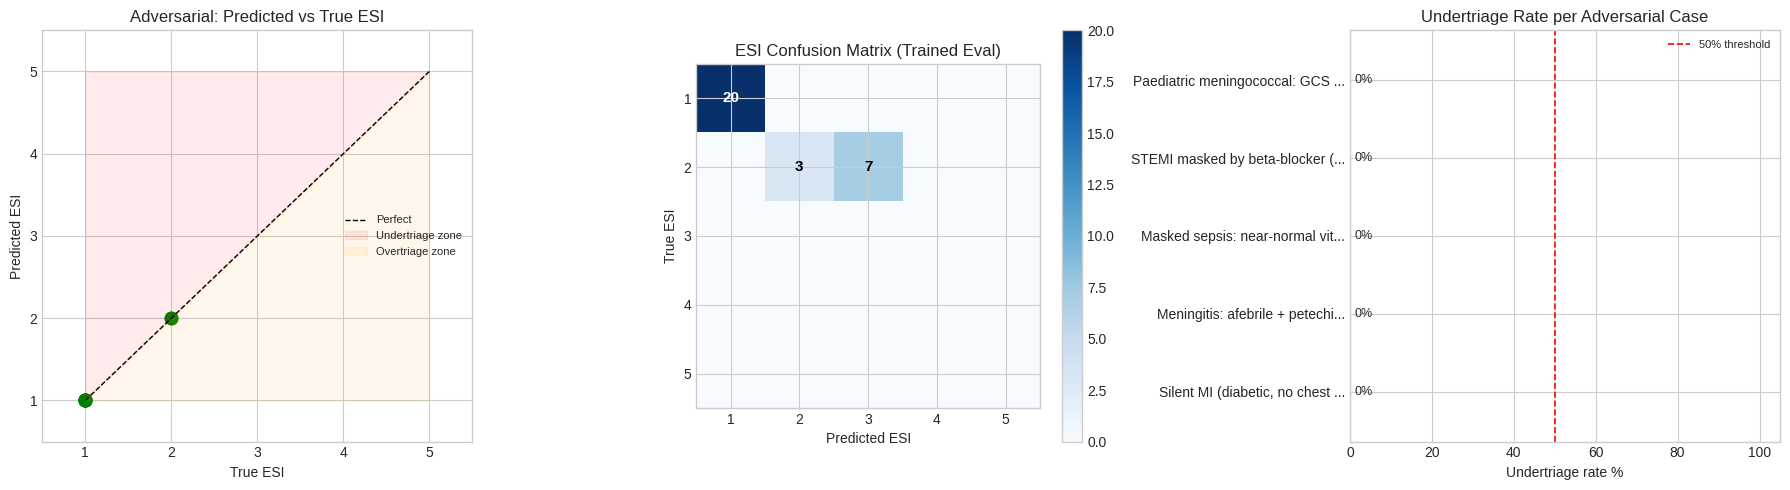

Undertriage analysis saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 - Adversarial predicted vs true ESI
ax = axes[0]
for r in adv_results:
    for p in r["preds"]:
        color = "red" if p > r["true_esi"] else ("green" if p == r["true_esi"] else "orange")
        ax.scatter(r["true_esi"], p, c=color, s=80, alpha=0.7)
ax.plot([1, 5], [1, 5], "k--", linewidth=1, label="Perfect")
ax.fill_between([1, 5], [1, 5], [5, 5], alpha=0.08, color="red", label="Undertriage zone")
ax.fill_between([1, 5], [1, 5], [1, 1], alpha=0.08, color="orange", label="Overtriage zone")
ax.set_xlabel("True ESI")
ax.set_ylabel("Predicted ESI")
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(fontsize=8)
ax.set_title("Adversarial: Predicted vs True ESI")

# 2 - Confusion matrix from trained eval set
ax2 = axes[1]
cm = np.zeros((5, 5), dtype=int)
for r in trained_records_full:
    true_esi = CORRECT_ESI_PER_TASK.get(r["task_id"], 3)
    pred_esi = r.get("pred_esi")
    if pred_esi is None:
        pred_esi = true_esi if r["esi_accurate"] else min(5, true_esi + 1)
    cm[true_esi - 1][int(pred_esi) - 1] += 1
im = ax2.imshow(cm, cmap="Blues", vmin=0)
ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_xticklabels([1, 2, 3, 4, 5])
ax2.set_yticklabels([1, 2, 3, 4, 5])
ax2.set_xlabel("Predicted ESI")
ax2.set_ylabel("True ESI")
for i in range(5):
    for j in range(5):
        if cm[i][j] > 0:
            color = "white" if cm[i][j] > cm.max() * 0.5 else "black"
            ax2.text(j, i, str(cm[i][j]), ha="center", va="center", color=color, fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax2)
ax2.set_title("ESI Confusion Matrix (Trained Eval)")

# 3 - Undertriage rate per adversarial case
ax3 = axes[2]
labels_short = [r["label"][:30] + "..." if len(r["label"]) > 30 else r["label"] for r in adv_results]
colors_bar = ["red" if r["undertriage_pct"] > 50 else ("orange" if r["undertriage_pct"] > 0 else "green") for r in adv_results]
bars = ax3.barh(labels_short, [r["undertriage_pct"] for r in adv_results], color=colors_bar)
ax3.set_xlabel("Undertriage rate %")
ax3.set_xlim(0, 105)
ax3.axvline(x=50, color="red", linestyle="--", linewidth=1.2, label="50% threshold")
for bar, r in zip(bars, adv_results):
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{r['undertriage_pct']:.0f}%", va="center", fontsize=9)
ax3.legend(fontsize=8)
ax3.set_title("Undertriage Rate per Adversarial Case")

plt.tight_layout()
plt.savefig("undertriage_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Undertriage analysis saved")

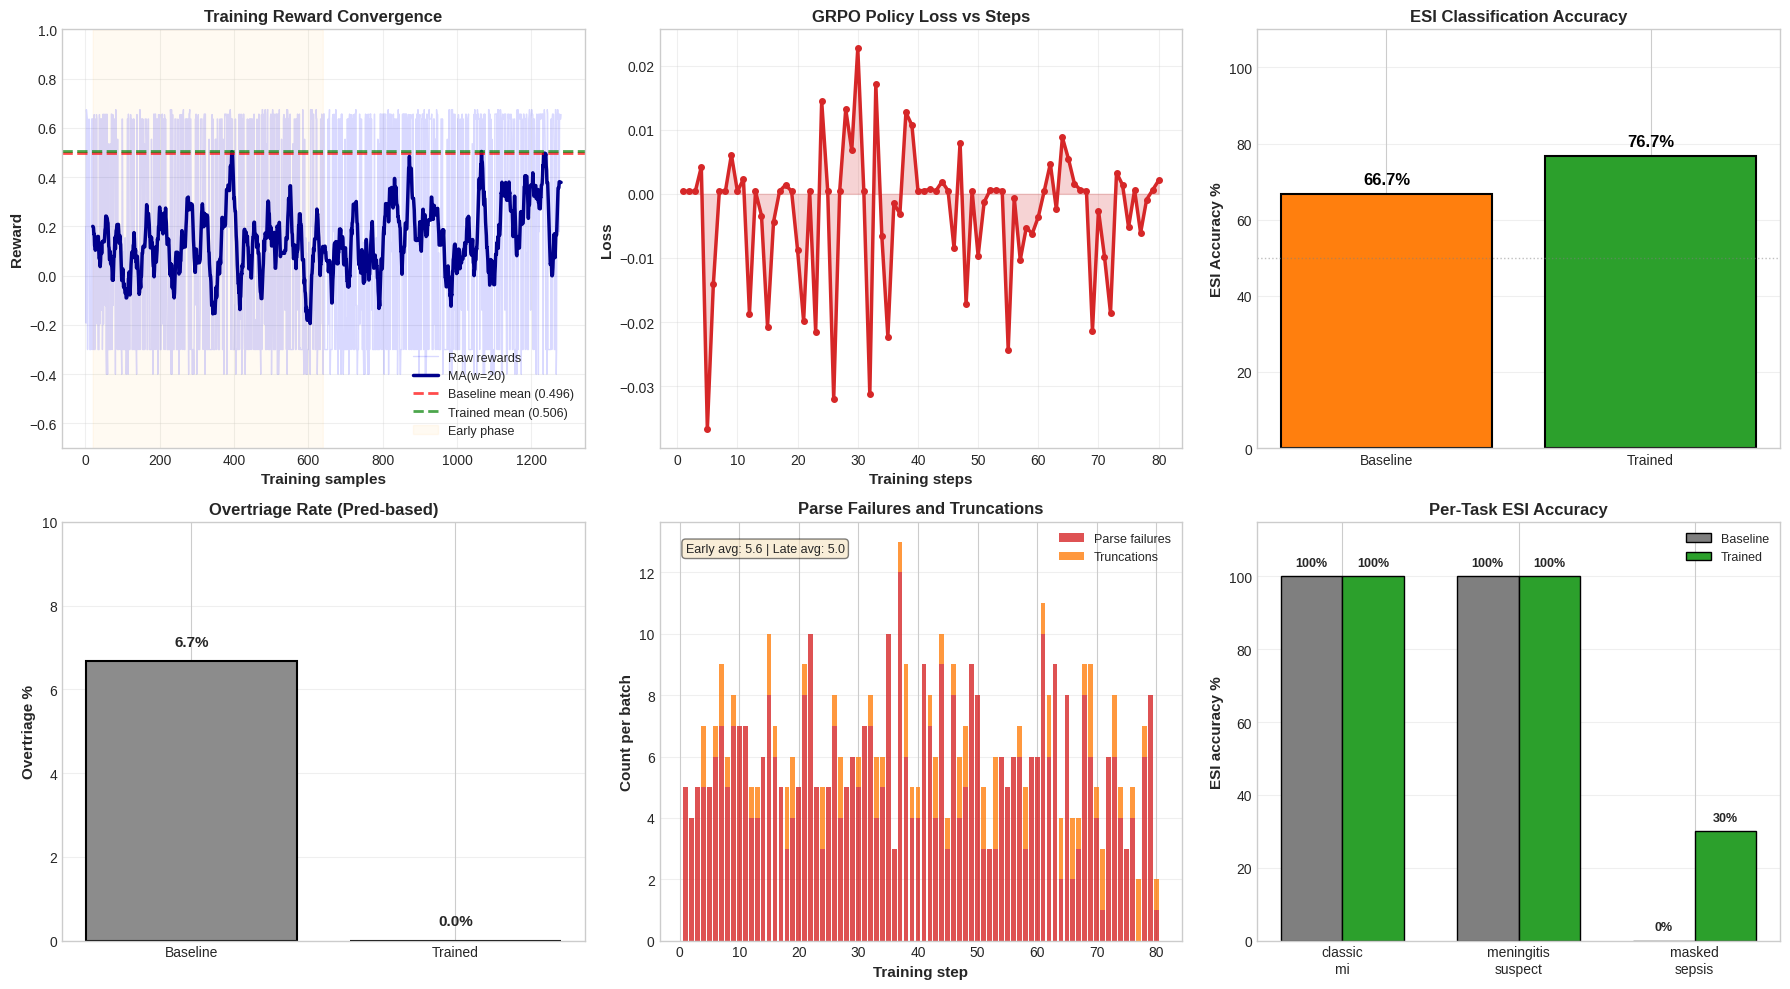

Cell 14 complete - enhanced plots saved as triage_grpo_v14_results_ENHANCED.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Use consistent metrics from pred-aware eval when available
plot_b_acc = float(acc_b) if "acc_b" in globals() else float(b_acc)
plot_t_acc = float(acc) if "acc" in globals() else float(t_acc)
plot_b_reward = float(b_reward)
plot_t_reward = float(t_reward)

# 1 - Reward curve with baseline and trained means
if _reward_log:
    r = np.array(_reward_log, dtype=float)
    x = np.arange(1, len(r) + 1)
    w = max(5, min(20, len(r) // 10))
    ma = np.convolve(r, np.ones(w) / w, mode="valid")

    axes[0].plot(x, r, alpha=0.15, linewidth=1, color="blue", label="Raw rewards")
    axes[0].plot(np.arange(w, len(r) + 1), ma, linewidth=2.5, color="darkblue", label=f"MA(w={w})")
    axes[0].axhline(y=plot_b_reward, color="red", linestyle="--", linewidth=2, label=f"Baseline mean ({plot_b_reward:.3f})", alpha=0.7)
    axes[0].axhline(y=plot_t_reward, color="green", linestyle="--", linewidth=2, label=f"Trained mean ({plot_t_reward:.3f})", alpha=0.7)
    axes[0].fill_between(np.arange(w, len(r) + 1), -1, 1, where=(np.arange(w, len(r) + 1) < len(r) // 2), alpha=0.05, color="orange", label="Early phase")
    axes[0].set_xlabel("Training samples", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Reward", fontsize=11, fontweight="bold")
    axes[0].set_ylim(-0.7, 1.0)
    axes[0].legend(loc="lower right", fontsize=9)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No reward log", ha="center", va="center")
axes[0].set_title("Training Reward Convergence", fontsize=12, fontweight="bold")

# 2 - Policy loss
log_h = getattr(getattr(grpo_trainer, "state", None), "log_history", [])
steps, losses = [], []
for e in log_h:
    if not isinstance(e, dict):
        continue
    s = e.get("step")
    l = next((float(e[k]) for k in ("policy_loss", "loss", "train/loss") if k in e), None)
    if s and l:
        steps.append(s)
        losses.append(l)
if steps:
    axes[1].plot(steps, losses, color="#d62728", linewidth=2.5, marker="o", markersize=4)
    axes[1].fill_between(steps, losses, alpha=0.2, color="#d62728")
    axes[1].set_xlabel("Training steps", fontsize=11, fontweight="bold")
    axes[1].set_ylabel("Loss", fontsize=11, fontweight="bold")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No loss log", ha="center", va="center")
axes[1].set_title("GRPO Policy Loss vs Steps", fontsize=12, fontweight="bold")

# 3 - Overall ESI accuracy
vals = [plot_b_acc, plot_t_acc]
colors_acc = ["#ff7f0e", "#2ca02c"]
bars = axes[2].bar(["Baseline", "Trained"], vals, color=colors_acc, edgecolor="black", linewidth=1.5)
axes[2].set_ylim(0, 110)
axes[2].set_ylabel("ESI Accuracy %", fontsize=11, fontweight="bold")
axes[2].axhline(y=50, color="gray", linestyle=":", alpha=0.5, linewidth=1)
for bar, v in zip(bars, vals):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, height + 2, f"{v:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold", color="black")
axes[2].grid(True, alpha=0.3, axis="y")
axes[2].set_title("ESI Classification Accuracy", fontsize=12, fontweight="bold")

# 4 - Overtriage comparison (fills removed panel)
if "b_over_pred" in globals() and "t_over_pred" in globals():
    over_vals = [float(b_over_pred), float(t_over_pred)]
else:
    base_src = baseline_records_full if "baseline_records_full" in globals() else []
    train_src = trained_records_full if "trained_records_full" in globals() else []
    b_over = 100.0 * np.mean([r.get("overtriage", 0) for r in base_src]) if len(base_src) else 0.0
    t_over = 100.0 * np.mean([r.get("overtriage", 0) for r in train_src]) if len(train_src) else 0.0
    over_vals = [b_over, t_over]

bars_over = axes[3].bar(["Baseline", "Trained"], over_vals, color=["#8c8c8c", "#1f77b4"], edgecolor="black", linewidth=1.5)
axes[3].set_ylabel("Overtriage %", fontsize=11, fontweight="bold")
axes[3].set_ylim(0, max(10, max(over_vals) * 1.5 if max(over_vals) > 0 else 5))
axes[3].grid(True, alpha=0.3, axis="y")
for bar, v in zip(bars_over, over_vals):
    height = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width() / 2, height + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[3].set_title("Overtriage Rate (Pred-based)", fontsize=12, fontweight="bold")

# 5 - Parse failures and truncations
if _parse_fail_log:
    pf = np.array(_parse_fail_log, dtype=float)
    tr = np.array(_trunc_log, dtype=float)
    x5 = np.arange(1, len(pf) + 1)

    axes[4].bar(x5, pf, label="Parse failures", alpha=0.8, color="#d62728", width=0.8)
    axes[4].bar(x5, tr, bottom=pf, label="Truncations", alpha=0.8, color="#ff7f0e", width=0.8)
    axes[4].set_xlabel("Training step", fontsize=11, fontweight="bold")
    axes[4].set_ylabel("Count per batch", fontsize=11, fontweight="bold")
    axes[4].legend(loc="upper right", fontsize=9)
    axes[4].grid(True, alpha=0.3, axis="y")

    third = max(1, len(pf) // 3)
    early_fail = pf[:third].mean()
    late_fail = pf[-third:].mean()
    axes[4].text(0.05, 0.95, f"Early avg: {early_fail:.1f} | Late avg: {late_fail:.1f}", ha="left", va="top", transform=axes[4].transAxes, fontsize=9, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
else:
    axes[4].text(0.5, 0.5, "No training data", ha="center", va="center")
axes[4].set_title("Parse Failures and Truncations", fontsize=12, fontweight="bold")

# 6 - Per-task accuracy (neutral title, consistent data source)
def _task_acc(records, task_id):
    task_rows = [r for r in records if r.get("task_id") == task_id]
    if not task_rows:
        return 0.0
    return 100.0 * float(np.mean([r.get("esi_accurate", 0) for r in task_rows]))

task_labels = TASK_IDS
base_src = baseline_records_full if "baseline_records_full" in globals() else (baseline_records if "baseline_records" in globals() else [])
train_src = trained_records_full if "trained_records_full" in globals() else (trained_records if "trained_records" in globals() else [])

b_task = [_task_acc(base_src, t) for t in task_labels]
t_task = [_task_acc(train_src, t) for t in task_labels]

x6 = np.arange(len(task_labels))
width = 0.35
bars_b = axes[5].bar(x6 - width / 2, b_task, width, label="Baseline", color="#7f7f7f", edgecolor="black", linewidth=1)
bars_t = axes[5].bar(x6 + width / 2, t_task, width, label="Trained", color="#2ca02c", edgecolor="black", linewidth=1)

axes[5].set_xticks(x6)
axes[5].set_xticklabels([t.replace("-", "\n") for t in task_labels], fontsize=10)
axes[5].set_ylim(0, 115)
axes[5].set_ylabel("ESI accuracy %", fontsize=11, fontweight="bold")
axes[5].legend(fontsize=9)
axes[5].grid(True, alpha=0.3, axis="y")
for bars in [bars_b, bars_t]:
    for bar in bars:
        height = bar.get_height()
        axes[5].text(bar.get_x() + bar.get_width() / 2, height + 2, f"{height:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[5].set_title("Per-Task ESI Accuracy", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("triage_grpo_v14_results_ENHANCED.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cell 14 complete - enhanced plots saved as triage_grpo_v14_results_ENHANCED.png")